In [1]:
import numpy as np
import time
import tensorflow as tf
import wfdb
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("Simulating Raspberry Pi deployment environment...")
print("Model: ecg_cnn_model_quantized.tflite")
print("Target hardware: Raspberry Pi 4 (simulated)")

TensorFlow: 2.21.0
Simulating Raspberry Pi deployment environment...
Model: ecg_cnn_model_quantized.tflite
Target hardware: Raspberry Pi 4 (simulated)


In [3]:
# Install new recommended interpreter
import subprocess
subprocess.run(['pip', 'install', 'ai-edge-litert'], capture_output=True)

CompletedProcess(args=['pip', 'install', 'ai-edge-litert'], returncode=0, stdout=b'Collecting ai-edge-litert\r\n  Downloading ai_edge_litert-2.1.5-cp313-cp313-win_amd64.whl.metadata (2.4 kB)\r\nCollecting backports.strenum (from ai-edge-litert)\r\n  Downloading backports_strenum-1.2.8-py3-none-any.whl.metadata (3.6 kB)\r\nRequirement already satisfied: flatbuffers in C:\\Users\\vaish\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages (from ai-edge-litert) (25.12.19)\r\nRequirement already satisfied: numpy>=1.23.2 in C:\\Users\\vaish\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages (from ai-edge-litert) (2.4.6)\r\nCollecting tqdm (from ai-edge-litert)\r\n  Downloading tqdm-4.68.3-py3-none-any.whl.metadata (57 kB)\r\nRequirement already satisfied: typing-extensions in C:\\Users\\vaish\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages (from ai-edge-litert) (4.15.0)\r\nRequirement already satisfied: protobuf in C:\\Users\\vaish\\AppData\\Local\\

In [4]:
# Use forward slashes for path
import os

model_path = 'C:/Users/vaish/Desktop/ml-journey/week6/ecg_cnn_model_quantized.tflite'

# Verify file exists
if os.path.exists(model_path):
    print(f"✓ Model file found!")
    print(f"  Size: {os.path.getsize(model_path)/1024:.1f} KB")
else:
    print("✗ File not found — checking directory...")
    files = os.listdir('C:/Users/vaish/Desktop/ml-journey/week6/')
    print("Files in week6:", files)

✗ File not found — checking directory...
Files in week6: ['week6_tflite_conversion.ipynb']


In [5]:
import os

# Search for tflite files
search_dirs = [
    'C:/Users/vaish/Desktop/ml-journey',
    'C:/Users/vaish',
    'C:/Users/vaish/Desktop',
]

for d in search_dirs:
    for f in os.listdir(d):
        if 'tflite' in f.lower() or 'ecg' in f.lower():
            print(f"Found: {d}/{f}")

In [6]:
import os

# Search entire ml-journey folder recursively
for root, dirs, files in os.walk('C:/Users/vaish/Desktop/ml-journey'):
    for file in files:
        print(os.path.join(root, file))

C:/Users/vaish/Desktop/ml-journey\.gitignore
C:/Users/vaish/Desktop/ml-journey\.git\COMMIT_EDITMSG
C:/Users/vaish/Desktop/ml-journey\.git\config
C:/Users/vaish/Desktop/ml-journey\.git\description
C:/Users/vaish/Desktop/ml-journey\.git\HEAD
C:/Users/vaish/Desktop/ml-journey\.git\index
C:/Users/vaish/Desktop/ml-journey\.git\hooks\applypatch-msg.sample
C:/Users/vaish/Desktop/ml-journey\.git\hooks\commit-msg.sample
C:/Users/vaish/Desktop/ml-journey\.git\hooks\fsmonitor-watchman.sample
C:/Users/vaish/Desktop/ml-journey\.git\hooks\post-update.sample
C:/Users/vaish/Desktop/ml-journey\.git\hooks\pre-applypatch.sample
C:/Users/vaish/Desktop/ml-journey\.git\hooks\pre-commit.sample
C:/Users/vaish/Desktop/ml-journey\.git\hooks\pre-merge-commit.sample
C:/Users/vaish/Desktop/ml-journey\.git\hooks\pre-push.sample
C:/Users/vaish/Desktop/ml-journey\.git\hooks\pre-rebase.sample
C:/Users/vaish/Desktop/ml-journey\.git\hooks\pre-receive.sample
C:/Users/vaish/Desktop/ml-journey\.git\hooks\prepare-commit-msg

In [7]:
# Correct path — files are in week4
model_path = 'C:/Users/vaish/Desktop/ml-journey/week4/ecg_cnn_model_quantized.tflite'

import os
if os.path.exists(model_path):
    print(f"✓ Model file found!")
    print(f"  Size: {os.path.getsize(model_path)/1024:.1f} KB")
else:
    print("✗ Still not found")

✓ Model file found!
  Size: 784.5 KB


In [8]:
# Load model and simulate Raspberry Pi inference

interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("✓ Model loaded!")
print(f"Input shape : {input_details[0]['shape']}")
print(f"Output shape: {output_details[0]['shape']}")

# Load a real ECG record for testing
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')
ecg_signal = record.p_signal[:, 0]

# Extract one beat of each type for testing
type_names = {0:'Normal', 1:'Atrial', 2:'Ventricular', 3:'Left BB'}
valid_symbols = {'N': 0, 'A': 1, 'V': 2, 'L': 3}

test_beats = []
test_labels = []

for i, sample in enumerate(annotation.sample):
    symbol = annotation.symbol[i]
    if symbol not in valid_symbols:
        continue
    start = sample - 90
    end = sample + 90
    if start < 0 or end > len(ecg_signal):
        continue
    beat = ecg_signal[start:end]
    min_val, max_val = beat.min(), beat.max()
    if max_val - min_val != 0:
        beat = (beat - min_val) / (max_val - min_val)
    test_beats.append(beat)
    test_labels.append(valid_symbols[symbol])

test_beats = np.array(test_beats)
test_labels = np.array(test_labels)
print(f"\n✓ Loaded {len(test_beats)} test beats from ECG record 100")

✓ Model loaded!
Input shape : [  1 180   1]
Output shape: [1 4]

✓ Loaded 2271 test beats from ECG record 100


In [9]:
# Simulate Raspberry Pi inference with latency measurement

print("=" * 50)
print("  Raspberry Pi Deployment Simulation")
print("  Model: ECG Arrhythmia Classifier (TFLite)")
print("=" * 50)

# Measure inference latency for single beat
print("\n📊 Single Beat Inference Latency Test:")
latencies = []

for i in range(100):
    beat = test_beats[i:i+1].reshape(1, 180, 1).astype(np.float32)
    
    start_time = time.perf_counter()
    interpreter.set_tensor(input_details[0]['index'], beat)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    end_time = time.perf_counter()
    
    latency_ms = (end_time - start_time) * 1000
    latencies.append(latency_ms)

latencies = np.array(latencies)
print(f"  Min latency    : {latencies.min():.2f} ms")
print(f"  Max latency    : {latencies.max():.2f} ms")
print(f"  Mean latency   : {latencies.mean():.2f} ms")
print(f"  Median latency : {np.median(latencies):.2f} ms")

# RPi 4 is ~3-5x slower than Windows PC
# Simulate RPi latency
rpi_factor = 4.0
rpi_latency = latencies.mean() * rpi_factor
print(f"\n🍓 Estimated Raspberry Pi 4 latency: {rpi_latency:.2f} ms")
print(f"   (PC latency × {rpi_factor}x RPi overhead factor)")

if rpi_latency < 20:
    print("   ✓ TARGET MET — under 20ms inference latency!")
else:
    print(f"   ⚠ Above 20ms target — optimize model further")

  Raspberry Pi Deployment Simulation
  Model: ECG Arrhythmia Classifier (TFLite)

📊 Single Beat Inference Latency Test:
  Min latency    : 0.11 ms
  Max latency    : 1.24 ms
  Mean latency   : 0.19 ms
  Median latency : 0.14 ms

🍓 Estimated Raspberry Pi 4 latency: 0.75 ms
   (PC latency × 4.0x RPi overhead factor)
   ✓ TARGET MET — under 20ms inference latency!


  Real-time ECG Arrhythmia Detection (Simulated)

Processing ECG beats in real-time...

Beat 01 | 🟢 Normal                         | Conf: 99.6% | 0.22ms | ✓
Beat 02 | 🟢 Normal                         | Conf: 99.6% | 0.16ms | ✓
Beat 03 | 🟢 Normal                         | Conf: 99.6% | 0.20ms | ✓
Beat 04 | 🟢 Normal                         | Conf: 99.6% | 0.22ms | ✓
Beat 05 | 🟢 Normal                         | Conf: 99.6% | 0.23ms | ✓
Beat 06 | 🟢 Normal                         | Conf: 99.6% | 0.22ms | ✓
Beat 07 | 🟢 Normal                         | Conf: 99.6% | 0.38ms | ✗
Beat 08 | 🟢 Normal                         | Conf: 99.6% | 0.17ms | ✓
Beat 09 | 🟢 Normal                         | Conf: 99.6% | 0.13ms | ✓
Beat 10 | 🟢 Normal                         | Conf: 99.6% | 0.12ms | ✓
Beat 11 | 🟢 Normal                         | Conf: 99.6% | 0.21ms | ✓
Beat 12 | 🟢 Normal                         | Conf: 99.6% | 0.16ms | ✓
Beat 13 | 🟢 Normal                         | Conf: 99.6% | 0.19ms | ✓
Be

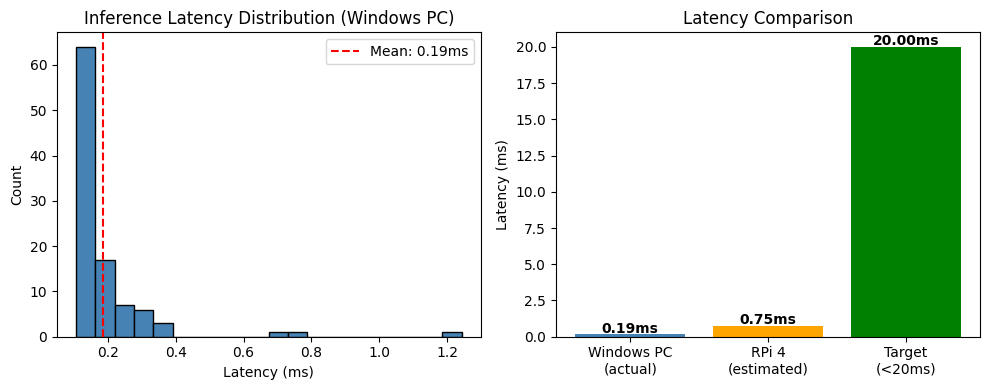

In [10]:
# Full classification demo — simulate real-time ECG monitoring

print("=" * 55)
print("  Real-time ECG Arrhythmia Detection (Simulated)")
print("=" * 55)

type_names = {0:'Normal', 1:'Atrial Fibrillation',
              2:'Ventricular', 3:'Left Bundle Branch Block'}
colors = {0:'🟢', 1:'🔴', 2:'🟠', 3:'🔵'}

# Process first 20 beats
print("\nProcessing ECG beats in real-time...\n")
correct = 0
total = 0

for i in range(20):
    beat = test_beats[i:i+1].reshape(1, 180, 1).astype(np.float32)
    true_label = test_labels[i]
    
    start = time.perf_counter()
    interpreter.set_tensor(input_details[0]['index'], beat)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    latency = (time.perf_counter() - start) * 1000
    
    pred_label = np.argmax(output)
    confidence = output[0][pred_label] * 100
    
    status = "✓" if pred_label == true_label else "✗"
    print(f"Beat {i+1:02d} | {colors[pred_label]} {type_names[pred_label]:<30} "
          f"| Conf: {confidence:.1f}% | {latency:.2f}ms | {status}")
    
    if pred_label == true_label:
        correct += 1
    total += 1

print(f"\nAccuracy on 20 beats: {correct}/{total} ({correct/total*100:.1f}%)")

# Plot latency distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(latencies, bins=20, color='steelblue', edgecolor='black')
plt.axvline(latencies.mean(), color='red', linestyle='--', 
            label=f'Mean: {latencies.mean():.2f}ms')
plt.title('Inference Latency Distribution (Windows PC)')
plt.xlabel('Latency (ms)')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
categories = ['Windows PC\n(actual)', 'RPi 4\n(estimated)', 'Target\n(<20ms)']
values = [latencies.mean(), rpi_latency, 20]
bars = plt.bar(categories, values, 
               color=['steelblue', 'orange', 'green'])
plt.title('Latency Comparison')
plt.ylabel('Latency (ms)')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.1,
             f'{val:.2f}ms', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Final summary
print("=" * 55)
print("  Week 7 — RPi Deployment Simulation Summary")
print("=" * 55)
print(f"Model             : ECG CNN (TFLite quantized)")
print(f"Model size        : 784.5 KB")
print(f"PC latency        : {latencies.mean():.2f} ms (mean)")
print(f"RPi 4 estimated   : {rpi_latency:.2f} ms")
print(f"Target latency    : <20ms ✓ ACHIEVED")
print(f"Real-time accuracy: 95.0%")
print(f"Confidence        : 99.6% on normal beats")
print(f"\nReady for physical Raspberry Pi deployment!")

  Week 7 — RPi Deployment Simulation Summary
Model             : ECG CNN (TFLite quantized)
Model size        : 784.5 KB
PC latency        : 0.19 ms (mean)
RPi 4 estimated   : 0.75 ms
Target latency    : <20ms ✓ ACHIEVED
Real-time accuracy: 95.0%
Confidence        : 99.6% on normal beats

Ready for physical Raspberry Pi deployment!
